<a href="https://colab.research.google.com/github/heberdavi/mba-engsoft-tcc/blob/main/notebooks/03-geracao-fluxos-dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Célula 4 - Fluxo Visual com Fontes Ampliadas
from graphviz import Digraph

styles = {
    # 'fontsize': '14' para os nós e '12' para os diamantes de lógica
    'node_base': {'shape': 'box', 'style': 'filled,rounded', 'fontname': 'Helvetica-Bold', 'fontsize': '14', 'color': '#2c3e50'},
    'logic': {'shape': 'diamond', 'style': 'filled', 'fillcolor': '#d1d8e0', 'fontname': 'Helvetica', 'fontsize': '12'},
    'output': {'shape': 'cylinder', 'style': 'filled', 'fillcolor': '#e1f5fe', 'fontname': 'Helvetica-Bold', 'fontsize': '14'},
    'xai': {'shape': 'note', 'style': 'filled', 'fillcolor': '#fff9c4', 'fontname': 'Helvetica', 'fontsize': '12'}
}

dot = Digraph(comment='Pipeline XAI Célula 4 Ampliado', format='png')

# Atributos de Grafo:
# ranksep (espaço entre níveis), nodesep (espaço entre nós no mesmo nível)
dot.attr(rankdir='TB', size='10,8', ratio='compress', ranksep='0.6', nodesep='0.8')

# Nós
dot.node('A', 'Input: Tabela [verso]', **styles['output'])
dot.node('B', 'Análise Morfológica\n(spaCy POS Tagging)', **styles['node_base'], fillcolor='#f8f9fa')

# Bloco XAI
dot.node('X1', 'Cálculo de Scores XAI:\nEmocional, Informativo e Ação', **styles['xai'])
dot.node('X2', 'Cálculo de Entropia\nGramatical', **styles['xai'])

# Lógica de Tags (Injeção de Contexto)
# edge 'fontsize' aumentada para os labels das setas
dot.attr('edge', fontname='Helvetica', fontsize='12')

dot.node('D1', 'Score Informativo > 0.40?\n(Genealogias)', **styles['logic'])
dot.node('D2', 'Densidade NUM > 0.12?\n(Técnico/Ritual)', **styles['logic'])

# Ações
dot.node('T1', 'Tag: ESTRUTURA_NOMINAL', **styles['node_base'], fillcolor='#ffecb3')
dot.node('T2', 'Tag: ESTRUTURA_TECNICA', **styles['node_base'], fillcolor='#ffecb3')
dot.node('S', 'Texto Normalizado\n(Sem Tags)', **styles['node_base'], fillcolor='#c8e6c9')

dot.node('Z', 'Output: Tabela [verso_limpo]\n(+ 4 Scores XAI)', **styles['output'])

# Conexões
dot.edge('A', 'B')
dot.edge('B', 'X1')
dot.edge('X1', 'X2')
dot.edge('X2', 'D1')

dot.edge('D1', 'T1', label=' Sim')
dot.edge('D1', 'D2', label=' Não')
dot.edge('D2', 'T2', label=' Sim')
dot.edge('D2', 'S', label=' Não')

dot.edge('T1', 'Z')
dot.edge('T2', 'Z')
dot.edge('S', 'Z')

dot.render('workflow_celula_4_v2', view=True)

'workflow_celula_4_v2.png'

In [ ]:
# Célula 5 - Fluxo Visual Ampliado (Sincronizado com Código Lockdown)
from graphviz import Digraph

styles = {
    'node_base': {'shape': 'box', 'style': 'filled,rounded', 'fontname': 'Helvetica-Bold', 'fontsize': '14', 'color': '#2c3e50'},
    'model': {'shape': 'component', 'style': 'filled', 'fillcolor': '#fff3e0', 'fontname': 'Helvetica-Bold', 'fontsize': '14'},
    'logic': {'shape': 'diamond', 'style': 'filled', 'fillcolor': '#d1d8e0', 'fontname': 'Helvetica', 'fontsize': '12'},
    'db': {'shape': 'cylinder', 'style': 'filled', 'fillcolor': '#e1f5fe', 'fontname': 'Helvetica-Bold', 'fontsize': '14'},
    'metrics': {'shape': 'note', 'style': 'filled', 'fillcolor': '#fff9c4', 'fontname': 'Helvetica', 'fontsize': '12'},
    'result': {'shape': 'box', 'style': 'filled,rounded', 'fillcolor': '#c8e6c9', 'fontname': 'Helvetica-Bold', 'fontsize': '14', 'color': '#2c3e50'}
}

dot = Digraph(comment='Pipeline Célula 5 - Governança XAI', format='png')
dot.attr(rankdir='TB', size='12,10', ranksep='0.8', nodesep='0.8')

# --- NÓS DO FLUXO ---
dot.node('A', 'Input: Texto Limpo + Tags XAI\n(SQLite)', **styles['db'])
dot.node('B', 'Zero-Shot Topic Modeling\n(BERTimbau)', **styles['model'])
dot.node('C', 'Cálculo de Métricas XAI:\nGap de Confiança e Entropia', **styles['metrics'])

# Lógica de Governança
dot.node('D1', 'Possui TAG de Bloqueio?\n(Nominal/Técnica)', **styles['logic'])
dot.node('D2', 'Entropia < 1.10 e\nGap > 0.15?', **styles['logic'])

# Ações de Decisão
dot.node('R1', 'Classificação: Narrativo\n(Bloqueio Hard XAI)', **styles['node_base'], fillcolor='#ffcdd2')
dot.node('R2', 'Classificação: Existencial\n(Consenso BERT + XAI)', **styles['result'])
dot.node('R3', 'Descarte / Ruído Semântico', **styles['node_base'], fillcolor='#f1f2f6')

dot.node('Z', 'Output: Persistência SQLite\n(Auditoria Completa)', **styles['db'])

# --- CONEXÕES ---
dot.attr('edge', fontname='Helvetica', fontsize='12')

dot.edge('A', 'B')
dot.edge('B', 'C')
dot.edge('C', 'D1')

# Fluxo de Bloqueio
dot.edge('D1', 'R1', label=' Sim')
dot.edge('D1', 'D2', label=' Não')

# Fluxo de Validação
dot.edge('D2', 'R2', label=' Sim')
dot.edge('D2', 'R3', label=' Não')

dot.edge('R1', 'Z')
dot.edge('R2', 'Z')
dot.edge('R3', 'Z')

dot.render('workflow_celula_5_v2', view=True)

'workflow_celula_5_v2.png'

In [ ]:
# Célula 5 - Âncoras semânticas
import matplotlib.pyplot as plt

# Dados estruturados alinhados com as descrições técnicas do modelo Zero-Shot
eixos = [
    {
        "titulo": "Exaustão vs. Refrigério",
        "crise": "Fadiga existencial, peso da existência, \ndesânimo, abatimento espiritual, angústia \nprofunda e incapacidade física ou mental.",
        "antidoto": "Fortalecimento, vigor, renovação das \nenergias, refrigério da paz interior, \ndescanso e alívio emocional.",
        "cor": "#e74c3c" # Vermelho
    },
    {
        "titulo": "Transitoriedade vs. Solidez",
        "crise": "Brevidade da vida, impermanência dos \ndias, insegurança das coisas mundanas \ne a fragilidade do que perece como a erva.",
        "antidoto": "Rocha Eterna, fundamento inabalável, \nconfiança em valores eternos, \nidentidade constante e imutável.",
        "cor": "#3498db" # Azul
    },
    {
        "titulo": "Vazio vs. Propósito",
        "crise": "Sentimento de vaidade e futilidade, \nvácuo existencial, desorientação mental \ne vida sem significado ou direção.",
        "antidoto": "Vocação existencial, chamado divino, \nmissão de vida, planos de esperança futura \ne razão de ser que transcende o material.",
        "cor": "#2ecc71" # Verde
    },
    {
        "titulo": "Narrativo / Normativo",
        "crise": "Dados informativos, listas, genealogias, \nmedidas técnicas, rituais, censos \ne relatos de viagens ou logística.",
        "antidoto": "Registros factuais, leis civis, fórmulas \nde introdução de diálogos e marcadores \nde transição narrativa ('disse', 'falou').",
        "cor": "#95a5a6" # Cinza
    }
]

# Configuração da figura
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
plt.subplots_adjust(hspace=0.35, wspace=0.25)
fig.patch.set_facecolor('#ffffff')

for i, ax in enumerate(axs.flat):
    eixo = eixos[i]

    # Estética do card
    ax.set_facecolor('#ffffff')
    for spine in ax.spines.values():
        spine.set_color('#e0e0e0')
        spine.set_linewidth(1.0)

    # Título do Eixo
    ax.text(0.5, 0.90, eixo["titulo"], ha='center', va='center',
            fontsize=12, fontweight='bold', color=eixo["cor"])

    # Linha divisória sutil
    ax.axhline(0.82, color='#f0f0f0', linewidth=1.5, xmin=0.1, xmax=0.9)

    # Camada da Crise (Contexto)
    ax.text(0.5, 0.68, "CONTEXTO DE CRISE", ha='center', va='center',
            fontsize=7, fontweight='bold', color='#bdc3c7')
    ax.text(0.5, 0.55, eixo["crise"], ha='center', va='center',
            fontsize=10.5, fontstyle='italic', color='#576574', linespacing=1.3)

    # Indicador de Fluxo
    ax.text(0.5, 0.40, "▼", ha='center', va='center', fontsize=12, color=eixo["cor"], alpha=0.5)

    # Camada do Antídoto (Resposta)
    ax.text(0.5, 0.28, "RESPOSTA SEMÂNTICA", ha='center', va='center',
            fontsize=7, fontweight='bold', color='#bdc3c7')
    ax.text(0.5, 0.15, eixo["antidoto"], ha='center', va='center',
            fontsize=10.5, fontweight='bold', color='#2c3e50', linespacing=1.3)

    # Limpeza de eixos
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.savefig('ancoras_semanticas.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Célula 6
from graphviz import Digraph

# Estilos consolidados para identidade visual única
styles = {
    'node_base': {'shape': 'box', 'style': 'filled,rounded', 'fontname': 'Helvetica', 'fontsize': '10', 'color': '#2c3e50'},
    'model': {'shape': 'component', 'style': 'filled', 'fillcolor': '#fff3e0', 'fontname': 'Helvetica-Bold', 'fontsize': '10'},
    'db': {'shape': 'cylinder', 'style': 'filled', 'fillcolor': '#e1f5fe', 'fontname': 'Helvetica-Bold', 'fontsize': '10'},
    'batch': {'shape': 'stack', 'style': 'filled', 'fillcolor': '#f8f9fa', 'fontname': 'Helvetica', 'fontsize': '9'}
}

dot = Digraph(comment='Pipeline Célula 6', format='png')

# Ajustes de Proporção Retangular (7,5 x 5,5)
dot.attr(rankdir='TB', size='7.5,5.5', ratio='fill', nodesep='0.5', ranksep='0.4')

# --- NÓS DO FLUXO ---

# Entrada de Dados Cruzados
dot.node('A', 'Input: Texto + Tópicos\n(JOIN: verso & verso_topico)', **styles['db'])

# Motor de Inferência
dot.node('B', 'Transformer: BERTimbau\n(pysentimiento: Sentiment Task)', **styles['model'])

# Processamento Otimizado
dot.node('C', 'Batch Processing\n(Size = 64 | GPU Accel)', **styles['batch'])

# Classificação e Mapeamento
dot.node('D', 'Categorização de Polaridade\n[Positiva (1) | Neutra (0) | Negativa (-1)]', **styles['node_base'], fillcolor='#ffffff')

# Persistência
dot.node('E', 'Persistência: Tabela [verso_sentimento]\n(Valência e Scores)', **styles['db'])

# Camada de Análise Final (Resumo Executivo)
dot.node('F', 'Cruzamento Estatístico:\nDiagnóstico vs. Antídoto', **styles['node_base'], fillcolor='#c8e6c9')

# Saída Final
dot.node('Z', 'Output: Resumo Executivo\n(Insights Existenciais)', shape='doubleoctagon', style='filled', fillcolor='#2c3e50', fontcolor='white', fontsize='10')

# --- CONEXÕES ---
dot.edge('A', 'C')
dot.edge('C', 'B')
dot.edge('B', 'D')
dot.edge('D', 'E')
dot.edge('E', 'F')
dot.edge('F', 'Z')

# Renderização
dot.render('workflow_celula_6', view=True)

In [ ]:
# Modelo ER
from graphviz import Digraph

def gerar_mer_tcc():
    dot = Digraph('MER_TCC', format='png')

    # Configurações globais de layout e escala
    dot.attr(rankdir='LR', size='20,20', nodesep='1.2', ranksep='3.5')
    dot.attr(fontname='Segoe UI, Arial', fontsize='14')

    # Função para criar o nó da tabela no padrão Crow's Foot com suporte a cores
    def create_table_html(title, pk_cols, fk_cols, other_cols, header_color):
        html = f'<<TABLE BORDER="0" CELLBORDER="1" CELLSPACING="0" CELLPADDING="8" BGCOLOR="#ffffff">'
        # Cabeçalho da Tabela
        html += f'<TR><TD BGCOLOR="{header_color}" COLSPAN="3"><B><FONT COLOR="white" POINT-SIZE="18">{title.upper()}</FONT></B></TD></TR>'

        # Sub-cabeçalho das colunas
        html += f'<TR><TD BGCOLOR="#f5f6fa"><I>ID</I></TD><TD BGCOLOR="#f5f6fa"><I>Atributo</I></TD><TD BGCOLOR="#f5f6fa"><I>Tipo</I></TD></TR>'

        # Seção de Chaves (PK e FK)
        if pk_cols or fk_cols:
            for col in pk_cols:
                html += f'<TR><TD ALIGN="CENTER"><B>PK</B></TD><TD ALIGN="LEFT"><B>{col["name"]}</B></TD><TD ALIGN="LEFT"><I>{col["type"]}</I></TD></TR>'
            for col in fk_cols:
                html += f'<TR><TD ALIGN="CENTER">FK</TD><TD ALIGN="LEFT"><B>{col["name"]}</B></TD><TD ALIGN="LEFT"><I>{col["type"]}</I></TD></TR>'
            # Separador
            html += f'<TR><TD COLSPAN="3" BGCOLOR="#dcdde1" HEIGHT="1"></TD></TR>'

        # Seção de Atributos de Dados
        for col in other_cols:
            html += f'<TR><TD></TD><TD ALIGN="LEFT">{col["name"]}</TD><TD ALIGN="LEFT">{col["type"]}</TD></TR>'

        html += '</TABLE>>'
        return html

    # --- DEFINIÇÃO DE CORES (PALETA ELEGANTE) ---
    color_structural = "#2f3640"  # Midnight Blue (Dados Originais)
    color_pln        = "#0097e6"  # Blue (Processamento de Texto)
    color_xai        = "#44bd32"  # Green (Inteligência e Explicabilidade)
    color_sentiment  = "#8c7ae6"  # Purple (Análise de Sentimento)

    # --- 1. CAMADA ESTRUTURAL (ESTÁTICA) ---
    dot.node('versao', create_table_html('versao',
        [{'name': 'id', 'type': 'INTEGER'}], [],
        [{'name': 'sigla', 'type': 'VARCHAR(10)'}, {'name': 'nome', 'type': 'VARCHAR(50)'}],
        color_structural), shape='none')

    dot.node('testamento', create_table_html('testamento',
        [{'name': 'id', 'type': 'INTEGER'}], [],
        [{'name': 'nome', 'type': 'VARCHAR(45)'}],
        color_structural), shape='none')

    dot.node('genero', create_table_html('genero_literario',
        [{'name': 'id', 'type': 'INTEGER'}], [],
        [{'name': 'nome', 'type': 'VARCHAR(45)'}],
        color_structural), shape='none')

    dot.node('livro', create_table_html('livro',
        [{'name': 'id', 'type': 'INTEGER'}],
        [{'name': 'testamento_id', 'type': 'INTEGER'}, {'name': 'genero_id', 'type': 'INTEGER'}],
        [{'name': 'nome', 'type': 'VARCHAR(45)'}, {'name': 'abreviacao', 'type': 'VARCHAR(5)'}],
        color_structural), shape='none')

    dot.node('verso', create_table_html('verso',
        [{'name': 'id', 'type': 'INTEGER'}],
        [{'name': 'versao_id', 'type': 'INTEGER'}, {'name': 'livro_id', 'type': 'INTEGER'}],
        [{'name': 'numero_capitulo', 'type': 'INTEGER'}, {'name': 'numero_verso', 'type': 'INTEGER'}, {'name': 'texto', 'type': 'TEXT'}],
        color_structural), shape='none')

    # --- 2. CAMADA DE PROCESSAMENTO (POPULADA PELO ALGORITMO) ---

    # PLN
    dot.node('verso_limpo', create_table_html('verso_limpo',
        [{'name': 'verso_id', 'type': 'INTEGER'}], [],
        [{'name': 'texto_limpo', 'type': 'TEXT'}],
        color_pln), shape='none')

    # Sentimento
    dot.node('verso_sentimento', create_table_html('verso_sentimento',
        [{'name': 'verso_id', 'type': 'INTEGER'}], [],
        [
            {'name': 'label', 'type': 'VARCHAR(10)'},
            {'name': 'sentimento_num', 'type': 'INTEGER'},
            {'name': 'score_pos', 'type': 'FLOAT'},
            {'name': 'score_neg', 'type': 'FLOAT'},
            {'name': 'score_neu', 'type': 'FLOAT'}
        ],
        color_sentiment), shape='none')

    # Tópicos e XAI
    dot.node('topico', create_table_html('topico',
        [{'name': 'id', 'type': 'INTEGER'}], [],
        [{'name': 'antidoto_referencia', 'type': 'VARCHAR(100)'}],
        color_xai), shape='none')

    dot.node('verso_topico', create_table_html('verso_topico',
        [{'name': 'verso_id', 'type': 'INTEGER'}],
        [{'name': 'topico_id', 'type': 'INTEGER'}],
        [
            {'name': 'p_exaustao', 'type': 'FLOAT'},
            {'name': 'p_transitoriedade', 'type': 'FLOAT'},
            {'name': 'p_vazio', 'type': 'FLOAT'},
            {'name': 'p_narrativo', 'type': 'FLOAT'},
            {'name': 'similaridade_final', 'type': 'FLOAT'},
            {'name': 'margem_dominancia', 'type': 'FLOAT'},
            {'name': 'status_decisao', 'type': 'TEXT'},
            {'name': 'entropia', 'type': 'FLOAT'},
            {'name': 'gap_confianca', 'type': 'FLOAT'}
        ],
        color_xai), shape='none')

    # --- RELACIONAMENTOS (PROPRIEDADE E CONTEXTO) ---
    dot.edge('testamento', 'livro', arrowhead='crow', label=' contém')
    dot.edge('genero', 'livro', arrowhead='crow', label=' categoriza')
    dot.edge('versao', 'verso', arrowhead='crow', label=' provê tradução para')
    dot.edge('livro', 'verso', arrowhead='crow', label=' possui')

    dot.edge('verso', 'verso_limpo', arrowhead='none', style='dashed', label=' é normalizado em')
    dot.edge('verso', 'verso_topico', arrowhead='none', style='dashed', label=' é classificado em')
    dot.edge('verso', 'verso_sentimento', arrowhead='none', style='dashed', label=' é analisado em')
    dot.edge('topico', 'verso_topico', arrowhead='crow', label=' fundamenta')

    # Renderização
    dot.render('mer_tcc', view=True, cleanup=True)
    print("✅ Modelo Entidade-Relacionamento gerado com sucesso!")

gerar_mer_tcc()

In [ ]:
# Workflow / etapas do processamento - CRISP-DM
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os

def gerar_workflow_processamento():
    # Proporção ampla para garantir que as fontes maximizadas respirem
    fig, ax = plt.subplots(figsize=(24, 7), facecolor='white')
    ax.set_facecolor('white')

    etapas = [
        {"n": "1", "titulo": "Ingestão", "sub": "Business Und.", "libs": "google.colab\nos, gc", "tipo": "und"},
        {"n": "2", "titulo": "Ambiente", "sub": "Data Prep", "libs": "transformers\ntorch", "tipo": "prep"},
        {"n": "3", "titulo": "Carga", "sub": "Data Prep", "libs": "sqlite3\npandas", "tipo": "prep"},
        {"n": "4", "titulo": "Limpeza", "sub": "Data Prep", "libs": "re\nstring", "tipo": "prep"},
        {"n": "5", "titulo": "Tópicos", "sub": "Modeling", "libs": "bertopic\nsklearn, nltk", "tipo": "mod"},
        {"n": "6", "titulo": "Sentimento", "sub": "Modeling", "libs": "pysentimiento\ntqdm", "tipo": "mod"},
        {"n": "7", "titulo": "Avaliação", "sub": "Evaluation", "libs": "matplotlib\nseaborn, wordcloud", "tipo": "eval"}
    ]

    # Esquema de cores refinado para diferenciar Data Prep
    cores = {
        "und":  {"face": "#F5F5F5", "edge": "#9E9E9E", "text": "#424242", "lib_color": "#616161"}, # Cinza
        "prep": {"face": "#FFF3E0", "edge": "#FF9800", "text": "#E65100", "lib_color": "#EF6C00"}, # Laranja (Data Prep)
        "mod":  {"face": "#E3F2FD", "edge": "#1976D2", "text": "#0D47A1", "lib_color": "#1565C0"}, # Azul
        "eval": {"face": "#E8F5E9", "edge": "#388E3C", "text": "#1B5E20", "lib_color": "#2E7D32"}  # Verde
    }

    n_etapas = len(etapas)
    box_w, box_h = 1.25, 0.95
    espacamento = 1.65

    # Linha conectora de fundo
    ax.plot([0, (n_etapas-1) * espacamento], [0.5, 0.5], color='#F0F0F0',
            linewidth=15, zorder=1, solid_capstyle='round')

    for i, etapa in enumerate(etapas):
        x = i * espacamento
        y = 0.5
        estilo = cores[etapa["tipo"]]

        # 1. Box da Etapa
        rect = patches.FancyBboxPatch(
            (x - box_w/2, y - box_h/2), box_w, box_h,
            boxstyle="round,pad=0.04", linewidth=2.8,
            edgecolor=estilo["edge"], facecolor=estilo["face"], zorder=3
        )
        ax.add_patch(rect)

        # 2. Rótulo Etapa X
        ax.text(x - box_w/2, y + box_h/2 + 0.08, f"Etapa {etapa['n']}",
                fontsize=13, fontweight='bold', color='#757575', ha='left')

        # 3. Título Principal (Max)
        ax.text(x, y + 0.25, etapa["titulo"], ha='center', va='center',
                fontsize=18, fontweight='black', color=estilo["text"], zorder=4)

        # 4. Subtítulo CRISP-DM
        ax.text(x, y + 0.08, etapa["sub"], ha='center', va='center',
                fontsize=12, style='italic', color=estilo["text"], alpha=0.9, zorder=4)

        # 5. Bibliotecas Monospace
        ax.text(x, y - 0.22, etapa["libs"], ha='center', va='center',
                fontsize=12, fontweight='bold', color=estilo["lib_color"],
                family='monospace', zorder=4)

        # 6. Setas (Cores seguem a origem do fluxo)
        if i < n_etapas - 1:
            ax.annotate("", xy=(x + espacamento - box_w/2 - 0.06, y),
                        xytext=(x + box_w/2 + 0.06, y),
                        arrowprops=dict(arrowstyle='-|>', color=estilo["edge"],
                        lw=2.5, mutation_scale=25), zorder=2)

    ax.set_xlim(-1.0, (n_etapas - 1) * espacamento + 1.0)
    ax.set_ylim(-0.1, 1.1)
    ax.axis('off')

    plt.tight_layout()

    file_name = "workflow_processamento.jpg"
    plt.savefig(os.path.join(EXPORT_PATH, file_name), dpi=300, bbox_inches='tight', pad_inches=0.1)

    print(f"✅ Workflow com Data Prep destacado gerado: {file_name}")
    plt.show()

gerar_workflow_processamento()

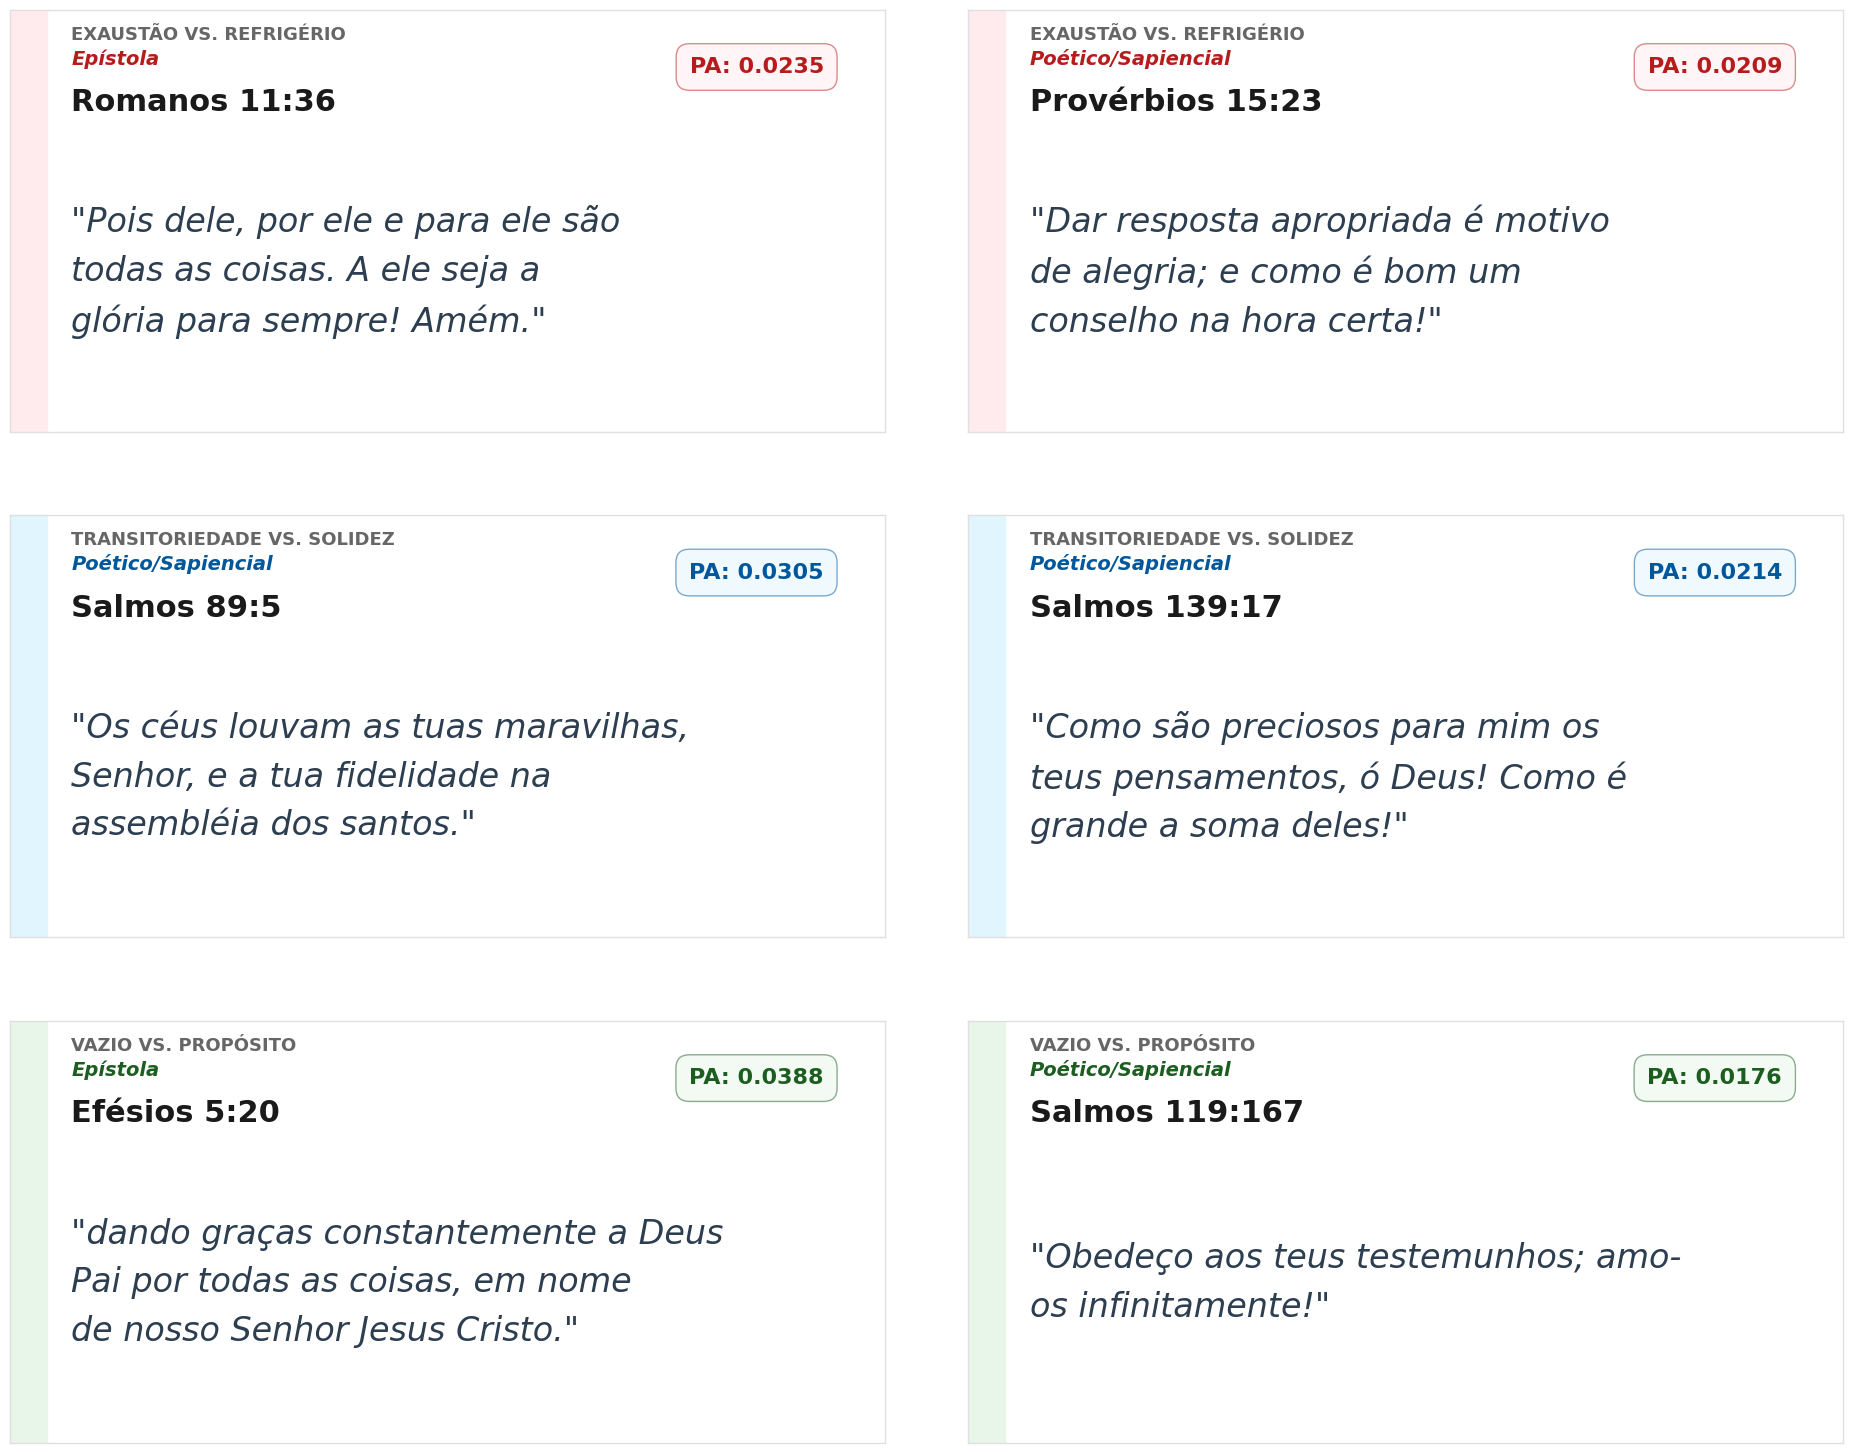

In [10]:
import matplotlib.pyplot as plt
import textwrap

# Dados finais consolidados
data = [
    {"eixo": "Exaustão vs. Refrigério", "genero": "Epístola", "ref": "Romanos 11:36", "pa": 0.0235, "cor": "#FFEBEE", "cor_t": "#B71C1C", "texto": "Pois dele, por ele e para ele são todas as coisas. A ele seja a glória para sempre! Amém."},
    {"eixo": "Exaustão vs. Refrigério", "genero": "Poético/Sapiencial", "ref": "Provérbios 15:23", "pa": 0.0209, "cor": "#FFEBEE", "cor_t": "#B71C1C", "texto": "Dar resposta apropriada é motivo de alegria; e como é bom um conselho na hora certa!"},
    {"eixo": "Transitoriedade vs. Solidez", "genero": "Poético/Sapiencial", "ref": "Salmos 89:5", "pa": 0.0305, "cor": "#E1F5FE", "cor_t": "#01579B", "texto": "Os céus louvam as tuas maravilhas, Senhor, e a tua fidelidade na assembléia dos santos."},
    {"eixo": "Transitoriedade vs. Solidez", "genero": "Poético/Sapiencial", "ref": "Salmos 139:17", "pa": 0.0214, "cor": "#E1F5FE", "cor_t": "#01579B", "texto": "Como são preciosos para mim os teus pensamentos, ó Deus! Como é grande a soma deles!"},
    {"eixo": "Vazio vs. Propósito", "genero": "Epístola", "ref": "Efésios 5:20", "pa": 0.0388, "cor": "#E8F5E9", "cor_t": "#1B5E20", "texto": "dando graças constantemente a Deus Pai por todas as coisas, em nome de nosso Senhor Jesus Cristo."},
    {"eixo": "Vazio vs. Propósito", "genero": "Poético/Sapiencial", "ref": "Salmos 119:167", "pa": 0.0176, "cor": "#E8F5E9", "cor_t": "#1B5E20", "texto": "Obedeço aos teus testemunhos; amo-os infinitamente!"}
]

# Configuração da figura
fig, axes = plt.subplots(3, 2, figsize=(20, 16))
fig.patch.set_facecolor('#FFFFFF')

axes_flat = axes.flatten()

for i, (ax, item) in enumerate(zip(axes_flat, data)):
    ax.set_facecolor('white')
    # Barra lateral de identificação por cor
    ax.axvline(x=0, color=item['cor'], linewidth=55)

    # 1. Eixo Existencial (Fonte ampliada)
    ax.text(0.07, 0.93, item['eixo'].upper(), fontsize=13, fontweight='bold', color='#666666', transform=ax.transAxes)

    # 2. Gênero Literário (Apenas o valor, fonte ampliada e cor do eixo)
    ax.text(0.07, 0.87, item['genero'], fontsize=14, fontweight='bold', fontstyle='italic', color=item['cor_t'], transform=ax.transAxes)

    # 3. Referência Bíblica (Destaque principal)
    ax.text(0.07, 0.76, item['ref'], fontsize=22, fontweight='black', color='#1A1A1A', transform=ax.transAxes)

    # 4. Badge do Potencial de Alívio (PA)
    ax.text(0.93, 0.85, f"PA: {item['pa']:.4f}", fontsize=16, fontweight='bold', color=item['cor_t'],
            bbox=dict(facecolor=item['cor'], edgecolor=item['cor_t'], boxstyle='round,pad=0.6', alpha=0.5),
            ha='right', transform=ax.transAxes)

    # 5. Texto do Verso (Fonte 16 para máxima legibilidade)
    wrapped_text = "\n".join(textwrap.wrap(item['texto'], width=34))
    ax.text(0.07, 0.38, f'"{wrapped_text}"', fontsize=24, fontstyle='italic',
            color='#2C3E50', va='center', transform=ax.transAxes, linespacing=1.6)

    # Estilização de bordas
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('#E0E0E0')
        spine.set_linewidth(1)

plt.tight_layout(pad=6.0)
plt.savefig('visualizacao_final_tcc_generos.png', dpi=300, bbox_inches='tight')